## Import Libraries and GPU Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# GPU setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Speed optimization
torch.backends.cudnn.benchmark = True



Using device: cpu


## Device Setup

## Load and Sort Dataset

In [3]:
df = pd.read_csv("../../data/indoorAir2.csv")

#df = pd.read_csv("../data/indoorAir2.csv")
# Convert timestamp once
df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s")

# Sort efficiently
df = df.sort_values("timestamp").reset_index(drop=True)

print(df.shape)        
df.head()

(1924653, 21)


,id,station_id,station_name,timestamp,scd41_co2,scd41_temperature,scd41_humidity,ens160_eco2,ens160_tvoc,ens160_aqi,...,svm41_humidity,svm41_nox_index,svm41_voc_index,bme688_temperature,bme688_humidity,bme688_pressure,bme688_gas_resistance,sfa30_temperature,sfa30_humidity,sfa30_hco
0,1,1,station_room_233,2024-11-13 16:57:56,488.0,22.951857,36.897277,418,32,1,...,34.060001,29.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,1,station_room_233,2024-11-13 16:58:57,485.0,22.335011,38.185119,414,30,1,...,34.209999,79.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,1,station_room_233,2024-11-13 16:59:59,477.0,22.353704,38.400268,443,43,1,...,34.180000,99.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,1,station_room_233,2024-11-13 17:01:03,474.0,22.417792,38.269042,406,26,1,...,34.130001,93.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,1,station_room_233,2024-11-13 17:02:05,473.0,22.556649,37.971496,416,31,1,...,34.240001,98.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Cyclic Time Feature Engineering

In [4]:
# Extract time information only once
hour = (df["timestamp"].dt.hour + df["timestamp"].dt.minute / 60)
dayofweek = df["timestamp"].dt.dayofweek

# Hour cyclic encoding
df["hour_sin"] = np.sin(2 * np.pi * hour / 24)
df["hour_cos"] = np.cos(2 * np.pi * hour / 24)

# Day of week cyclic encoding
df["dayofweek_sin"] = np.sin(2 * np.pi * dayofweek / 7)
df["dayofweek_cos"] = np.cos(2 * np.pi * dayofweek / 7)

# Weekend feature
df["is_weekend"] = (dayofweek.isin([5, 6]).astype(int))

# Final feature dataframe
feature_df = df[
    [
        "ens160_aqi",
        "ens160_tvoc",
        "bme688_gas_resistance",
        "bme688_pressure",
        "scd41_temperature",
        "scd41_humidity",
        "timestamp",
        "scd41_co2",
        "hour_sin",
        "hour_cos",
        "dayofweek_sin",
        "dayofweek_cos",
        "is_weekend",
        "station_id",
    ]
].copy()

print("Feature Data Shape:", feature_df.shape)
feature_df.head()

Feature Data Shape: (1924653, 14)


,ens160_aqi,ens160_tvoc,bme688_gas_resistance,bme688_pressure,scd41_temperature,scd41_humidity,timestamp,scd41_co2,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,is_weekend,station_id
0,1,32,NaN,NaN,22.951857,36.897277,2024-11-13 16:57:56,488.0,-0.962455,-0.271440,0.974928,-0.222521,0,1
1,1,30,NaN,NaN,22.335011,38.185119,2024-11-13 16:58:57,485.0,-0.963630,-0.267238,0.974928,-0.222521,0,1
2,1,43,NaN,NaN,22.353704,38.400268,2024-11-13 16:59:59,477.0,-0.964787,-0.263031,0.974928,-0.222521,0,1
3,1,26,NaN,NaN,22.417792,38.269042,2024-11-13 17:01:03,474.0,-0.967046,-0.254602,0.974928,-0.222521,0,1
4,1,31,NaN,NaN,22.556649,37.971496,2024-11-13 17:02:05,473.0,-0.968148,-0.250380,0.974928,-0.222521,0,1


## Train Validation Test Split

In [5]:
# Define station groups
train_stations = [1, 2, 4, 6]
val_stations = [3]
test_stations = [5]

# Create train validation and test datasets
train_df = feature_df[feature_df["station_id"].isin(train_stations)].copy()
val_df = feature_df[feature_df["station_id"].isin(val_stations)].copy()
test_df = feature_df[feature_df["station_id"].isin(test_stations)].copy()

# Print dataset shapes
print("Train Shape      :", train_df.shape)
print("Validation Shape :", val_df.shape)
print("Test Shape       :", test_df.shape)

# Verify station distribution
print("\nTrain Stations:", train_df["station_id"].unique())
print("Validation Stations:", val_df["station_id"].unique())
print("Test Stations:", test_df["station_id"].unique())

Train Shape      : (1310556, 14)
Validation Shape : (361836, 14)
Test Shape       : (252261, 14)

Train Stations: [1 2 4 6]
Validation Stations: [3]
Test Stations: [5]


## Remove Large Timestamp Gaps

In [6]:
def remove_large_gaps(data, threshold_hours=3):
    data = data.copy()

    # Ensure timestamp is datetime index
    if "timestamp" in data.columns:
        data["timestamp"] = pd.to_datetime(data["timestamp"])
        data = data.sort_values("timestamp").set_index("timestamp")
    else:
        data.index = pd.to_datetime(data.index)
        data = data.sort_index()

    # Calculate time differences
    time_diff = data.index.to_series().diff()
    gap_threshold = pd.Timedelta(hours=threshold_hours)

    # Identify large gaps
    large_gaps = time_diff > gap_threshold
    print("Large gaps found:",large_gaps.sum())

    # Remove rows after large gaps
    cleaned_data = data.loc[~large_gaps]
    return cleaned_data


# Apply gap removal
train_df = remove_large_gaps(train_df)
val_df = remove_large_gaps(val_df)
test_df = remove_large_gaps(test_df)

# Print final shapes
print("\nAfter Removing Large Gaps")
print("Train Shape      :", train_df.shape)
print("Validation Shape :", val_df.shape)
print("Test Shape       :", test_df.shape)

Large gaps found: 10
Large gaps found: 14
Large gaps found: 9

After Removing Large Gaps
Train Shape      : (1310546, 13)
Validation Shape : (361822, 13)
Test Shape       : (252252, 13)


## Resample Each Station Separately

In [7]:
def resample_station_data(data, freq="15min"):

    station_data_list = []
    # Process each station separately
    for station in data["station_id"].unique():
        # Select one station
        station_df = data[
            data["station_id"] == station
        ].copy()
        # Sort by timestamp index
        station_df = station_df.sort_index()
        # Resample
        station_df = station_df.resample(freq).mean()
        # Restore station ID
        station_df["station_id"] = station
        # Store result
        station_data_list.append(station_df)

    # Combine all stations
    final_df = pd.concat(station_data_list)
    return final_df

# Apply resampling
train_df = resample_station_data(train_df)
val_df = resample_station_data(val_df)
test_df = resample_station_data(test_df)

# Print shapes after resampling
print("After Resampling\n")
print("Train Shape      :", train_df.shape)
print("Validation Shape :", val_df.shape)
print("Test Shape       :", test_df.shape)

After Resampling

Train Shape      : (113528, 13)
Validation Shape : (44163, 13)
Test Shape       : (29203, 13)


## Handle Missing Values

In [8]:
def handle_missing_values(data):
    # Time-based interpolation
    data = data.interpolate(method="time")
    
    # Forward fill remaining missing values
    data = data.ffill()
    
    # Backward fill remaining missing values
    data = data.bfill()
    
    # Drop any remaining NaN values
    data = data.dropna()   
    return data
    
# Apply missing value handling
train_df = handle_missing_values(train_df)
val_df = handle_missing_values(val_df)
test_df = handle_missing_values(test_df)

# Check missing values
print("Train Missing Values      :", train_df.isna().sum().sum())
print("Validation Missing Values :", val_df.isna().sum().sum())
print("Test Missing Values       :", test_df.isna().sum().sum())

# Final dataset shapes
print("\nAfter Missing Value Handling\n")
print("Train Shape      :", train_df.shape)
print("Validation Shape :", val_df.shape)
print("Test Shape       :", test_df.shape)

Train Missing Values      : 0
Validation Missing Values : 0
Test Missing Values       : 0

After Missing Value Handling

Train Shape      : (113528, 13)
Validation Shape : (44163, 13)
Test Shape       : (29203, 13)


## Feature Scaling and Normalization

In [9]:
feature_columns = [

    "ens160_aqi",
    "ens160_tvoc",
    "bme688_gas_resistance",
    "bme688_pressure",
    "scd41_temperature",
    "scd41_humidity",
    "scd41_co2",

    "hour_sin",
    "hour_cos",

    "dayofweek_sin",
    "dayofweek_cos",

    "is_weekend"
]

# Keep only existing columns
feature_columns = [
    col for col in feature_columns
    if col in train_df.columns
]

# Select features
train_features = train_df[feature_columns]
val_features = val_df[feature_columns]
test_features = test_df[feature_columns]

# Initialize scaler
scaler = MinMaxScaler()

# Fit only on training data
train_scaled = scaler.fit_transform(train_features)
val_scaled = scaler.transform(val_features)
test_scaled = scaler.transform(test_features)

# Print scaled data shapes
print("Train Scaled Shape      :", train_scaled.shape)
print("Validation Scaled Shape :", val_scaled.shape)
print("Test Scaled Shape       :", test_scaled.shape)

Train Scaled Shape      : (113528, 12)
Validation Scaled Shape : (44163, 12)
Test Scaled Shape       : (29203, 12)


## Visualize Normalization Results

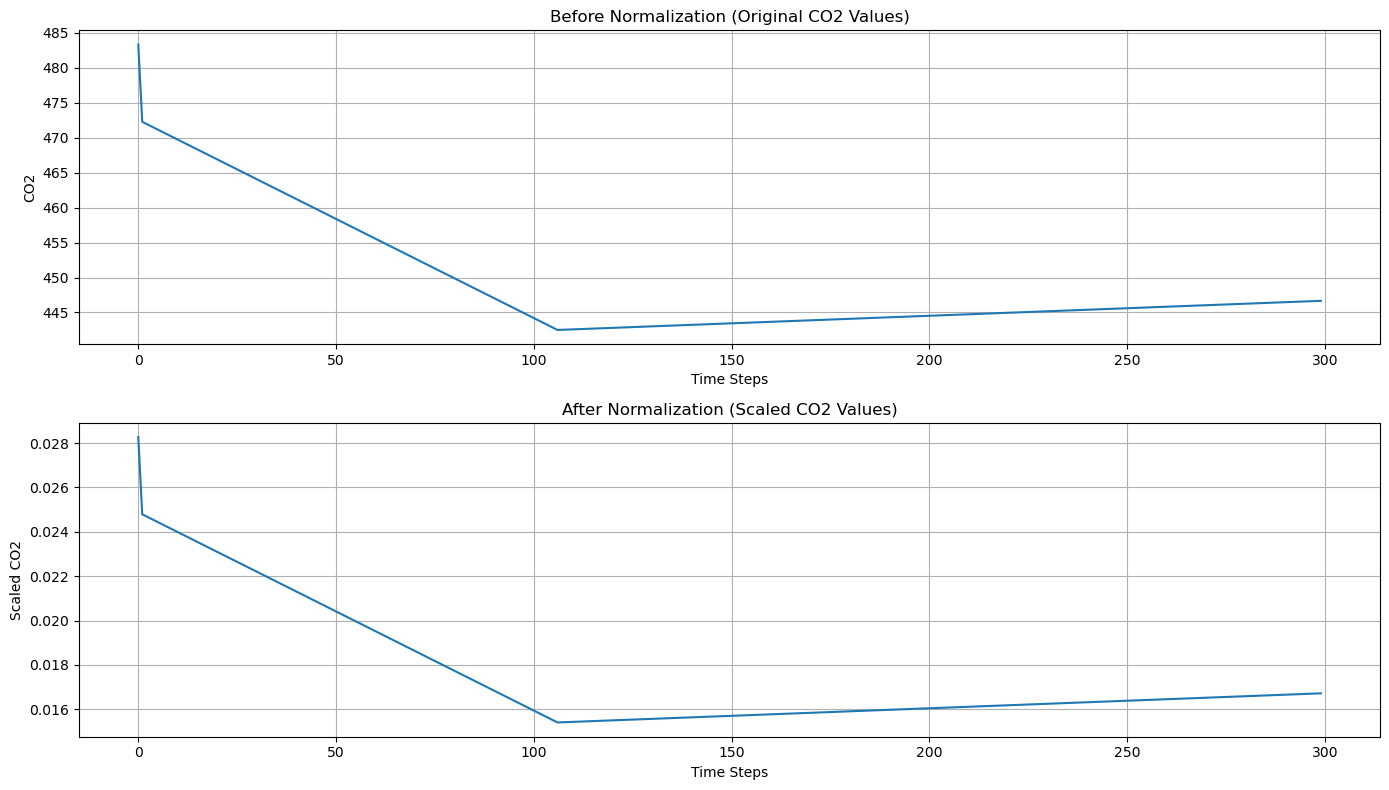


Original CO2 Range:
Min: 393.57142857142856
Max: 3568.9333333333334

Normalized CO2 Range:
Min: 0.0
Max: 0.9999999999999999

Sample Normalized Data:

[[0.07692308 0.00262835 0.66264059 0.69152697 0.31619735 0.35684166
  0.02826824 0.01795688 0.36642707 1.         0.35689587 0.        ]
 [0.07692308 0.00201686 0.66264059 0.69152697 0.32688945 0.35343745
  0.02478908 0.01463808 0.37909097 1.         0.35689587 0.        ]]


In [10]:
TARGET_LABELS = {
    "scd41_co2": "CO2",
    "ens160_aqi": "AQI",
    "ens160_tvoc": "TVOC",
    "bme688_gas_resistance": "Gas Resistance",
    "bme688_pressure": "Pressure",
    "scd41_temperature": "Temperature",
    "scd41_humidity": "Humidity",
}


def get_target_label(target_feature):
    return TARGET_LABELS.get(
        target_feature,
        target_feature.replace("_", " ").title()
    )


# Experiment settings. Change these values here only.
SEQ_LENGTH = 96
OUTPUT_LENGTH = 24

# Change this value when you want to predict a different sensor target.
# Examples: "scd41_co2","ens160_aqi", "ens160_tvoc", "bme688_gas_resistance",
# "bme688_pressure", "scd41_temperature", "scd41_humidity"
TARGET_FEATURE = "scd41_co2"
target_label = get_target_label(TARGET_FEATURE)

# Index of target feature
feature_index = feature_columns.index(TARGET_FEATURE)

# Create comparison plots
fig, axes = plt.subplots(2,1,figsize=(14, 8))

# Before normalization
axes[0].plot(train_features[TARGET_FEATURE].iloc[:300].values)
axes[0].set_title(f"Before Normalization (Original {target_label} Values)")
axes[0].set_ylabel(target_label)
axes[0].set_xlabel("Time Steps")
axes[0].grid(True)

# After normalization
axes[1].plot(train_scaled[:300, feature_index])
axes[1].set_title(f"After Normalization (Scaled {target_label} Values)")
axes[1].set_ylabel(f"Scaled {target_label}")
axes[1].set_xlabel("Time Steps")
axes[1].grid(True)
plt.tight_layout()
plt.show()

# Print scaling statistics
print(f"\nOriginal {target_label} Range:")
print("Min:", train_features[TARGET_FEATURE].min())
print("Max:", train_features[TARGET_FEATURE].max())

print(f"\nNormalized {target_label} Range:")
print("Min:", train_scaled[:, feature_index].min())
print("Max:", train_scaled[:, feature_index].max())

# Display sample normalized rows
print("\nSample Normalized Data:\n")
print(train_scaled[:2])

## Create Time Series Sequences

In [11]:
if TARGET_FEATURE not in feature_columns:
    raise ValueError(
        f"TARGET_FEATURE '{TARGET_FEATURE}' is not in feature_columns. "
        f"Available columns: {feature_columns}"
    )

target_index = feature_columns.index(TARGET_FEATURE)

# Sequence generation function
def create_sequences(
    data,
    seq_length,
    output_length,
    target_index
):

    X = []
    y = []
    for i in range(
        len(data) - seq_length - output_length
    ):

        # Input sequence
        X.append(data[i : i + seq_length])

        # Multi-step targets
        y.append(

            data[
                i + seq_length :

                i + seq_length + output_length,

                target_index
            ]
        )

    return np.array(X), np.array(y)


# Generate sequences
X_train, y_train = create_sequences(
    train_scaled,
    SEQ_LENGTH,
    OUTPUT_LENGTH,
    target_index
)

X_val, y_val = create_sequences(
    val_scaled,
    SEQ_LENGTH,
    OUTPUT_LENGTH,
    target_index
)

X_test, y_test = create_sequences(
    test_scaled,
    SEQ_LENGTH,
    OUTPUT_LENGTH,
    target_index
)

# Print shapes
print("X_train shape :", X_train.shape)
print("y_train shape :", y_train.shape)
print("\nX_val shape   :", X_val.shape)
print("y_val shape   :", y_val.shape)
print("\nX_test shape  :", X_test.shape)
print("y_test shape  :", y_test.shape)

X_train shape : (113408, 96, 12)
y_train shape : (113408, 24)

X_val shape   : (44043, 96, 12)
y_val shape   : (44043, 24)

X_test shape  : (29083, 96, 12)
y_test shape  : (29083, 24)


## Convert Data to PyTorch Tensors

In [12]:
# Device configuration
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)
print("Using Device:", device)

# Convert training data
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

# Convert validation data
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)

# Convert testing data
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

# Print tensor shapes
print("X_train tensor shape :", X_train.shape)
print("y_train tensor shape :", y_train.shape)
print("\nX_val tensor shape   :", X_val.shape)
print("y_val tensor shape   :", y_val.shape)
print("\nX_test tensor shape  :", X_test.shape)
print("y_test tensor shape  :", y_test.shape)

Using Device: cpu


X_train tensor shape : torch.Size([113408, 96, 12])
y_train tensor shape : torch.Size([113408, 24])

X_val tensor shape   : torch.Size([44043, 96, 12])
y_val tensor shape   : torch.Size([44043, 24])

X_test tensor shape  : torch.Size([29083, 96, 12])
y_test tensor shape  : torch.Size([29083, 24])


## Create Optimized DataLoaders

In [13]:
# Common DataLoader parameters
#BATCH_SIZE = 32
BATCH_SIZE = 64

loader_params = {
    "batch_size": BATCH_SIZE,
    "num_workers": 2,
    "pin_memory": False # needs to be true for NVIDIA CUDA GPUs
}

# Create DataLoaders
train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    shuffle=True,
    **loader_params
)
val_loader = DataLoader(
    TensorDataset(X_val, y_val),
    shuffle=False,
    **loader_params
)
test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    shuffle=False,
    **loader_params
)

# Check one batch
for X_batch, y_batch in train_loader:

    print("Batch X shape :", X_batch.shape)
    print("Batch y shape :", y_batch.shape)

    break

Batch X shape : torch.Size([64, 96, 12])
Batch y shape : torch.Size([64, 24])


## Positional Encoding Layer

In [14]:
class PositionalEncoding(nn.Module):

    def __init__(
        self,
        d_model,
        max_len=5000
    ):

        super().__init__()
        # Create positional encoding matrix
        pe = torch.zeros(max_len, d_model)

        # Position indices
        position = torch.arange(0, max_len).unsqueeze(1)

        # Exponential scaling term
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))

        # Apply sine to even indices
        pe[:, 0::2] = torch.sin(position * div_term)

        # Apply cosine to odd indices
        pe[:, 1::2] = torch.cos(position * div_term)

        # Add batch dimension
        pe = pe.unsqueeze(0)

        # Register as non-trainable buffer
        self.register_buffer("pe", pe)

    def forward(self, x):

        # Add positional encoding
        x = x + self.pe[:, :x.size(1)]

        return x

## Transformer Forecasting Model

In [15]:
class TransformerModel(nn.Module):

    def __init__(
        self,
        input_dim,
        output_length,
        d_model=64,
        nhead=4,
        num_layers=2,
        dropout=0.1
    ):
        
        super().__init__()

        # Input projection layer
        self.input_projection = nn.Linear(input_dim, d_model)

        # Positional encoding
        self.positional_encoding = PositionalEncoding(d_model)

        # Transformer encoder layer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dropout=dropout,
            batch_first=True
        )

        # Transformer encoder
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )
    
        # Dropout layer
        self.dropout = nn.Dropout(dropout)

        # Final prediction layer
        self.fc = nn.Linear(d_model, output_length)

    def forward(self, x):

        # Input projection
        x = self.input_projection(x)

        # Add positional encoding
        x = self.positional_encoding(x)

        # Transformer encoder
        x = self.transformer_encoder(x)

        # Global average pooling
        x = x.mean(dim=1)
      
        # Dropout
        x = self.dropout(x)

        # Final prediction
        x = self.fc(x)

        return x

## Initialize Transformer Model

In [16]:
# Initialize model
model = TransformerModel(
    input_dim=len(feature_columns),
    output_length=OUTPUT_LENGTH
)

# Print model architecture
print(model)

TransformerModel(
  (input_projection): Linear(in_features=12, out_features=64, bias=True)
  (positional_encoding): PositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (fc): Linear(in_features=64, out_features=24, bias=True)
)


## Loss Function Optimizer and Scheduler

In [17]:
# Loss function
criterion = nn.HuberLoss()

# Optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=0.0005,
    weight_decay=1e-5
)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=3,
    factor=0.5
)

# Training epochs
#EPOCHS = 10
EPOCHS = 8
print("Loss function initialized : HuberLoss")
print("Optimizer initialized     : AdamW")
print("Scheduler initialized     : ReduceLROnPlateau")

#Device checking
print(device)
print(torch.backends.mps.is_available())
print(torch.backends.mps.is_built())

Loss function initialized : HuberLoss
Optimizer initialized     : AdamW
Scheduler initialized     : ReduceLROnPlateau
cpu
False
False


## Transformer Training Loop

In [18]:
train_losses = []
val_losses = []

# Training loop
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0

    # Training batches
    for X_batch, y_batch in train_loader:

        # Move data to device
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        predictions = model(X_batch)

        # Compute loss
        loss = criterion(
            predictions,
            y_batch
        )

        # Backpropagation
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        # Update weights
        optimizer.step()

        # Accumulate training loss
        train_loss += loss.item()

    # Average training loss
    avg_train_loss = (train_loss / len(train_loader))

    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            # Move to device
            X_batch = X_batch.to(device)

            y_batch = y_batch.to(device)

            # Forward pass
            predictions = model(X_batch)

            # Validation loss
            loss = criterion(
                predictions,
                y_batch
            )
            val_loss += loss.item()

    # Average validation loss
    avg_val_loss = (val_loss / len(val_loader))

    # Store losses
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    # Scheduler step
    scheduler.step(avg_val_loss)
    # Print epoch results
    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {avg_train_loss:.6f} | "
        f"Validation Loss: {avg_val_loss:.6f}"
    )

Epoch [1/8] | Train Loss: 0.002486 | Validation Loss: 0.001288
Epoch [2/8] | Train Loss: 0.001025 | Validation Loss: 0.001177
Epoch [3/8] | Train Loss: 0.000928 | Validation Loss: 0.001201
Epoch [4/8] | Train Loss: 0.000881 | Validation Loss: 0.001183
Epoch [5/8] | Train Loss: 0.000840 | Validation Loss: 0.001174
Epoch [6/8] | Train Loss: 0.000812 | Validation Loss: 0.001234
Epoch [7/8] | Train Loss: 0.000772 | Validation Loss: 0.001398
Epoch [8/8] | Train Loss: 0.000724 | Validation Loss: 0.001368


## Model Evaluation

In [19]:
# Set model to evaluation mode
model.eval()
predictions = []

# Disable gradient calculation
with torch.no_grad():
    for X_batch, y_batch in test_loader:

        # Move batch to device
        X_batch = X_batch.to(device)

        # Model predictions
        outputs = model(X_batch)

        # Move predictions to CPU
        predictions.extend(outputs.cpu().numpy())

# Convert predictions to NumPy array
predictions = np.array(predictions)

# Actual target values
actual = y_test.numpy()

# Evaluation metrics
mse = mean_squared_error(actual, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actual,predictions)

# Print results
print("\nTransformer Model Evaluation Metrics\n")
print(f"MSE  : {mse:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"MAE  : {mae:.6f}")


from sklearn.metrics import r2_score

r2 = r2_score(
    actual.flatten(),
    predictions.flatten()
)

print(f"R² Score : {r2:.6f}")



Transformer Model Evaluation Metrics

MSE  : 0.001735
RMSE : 0.041648
MAE  : 0.023165
R² Score : 0.732049


## Actual vs Predicted Visualization

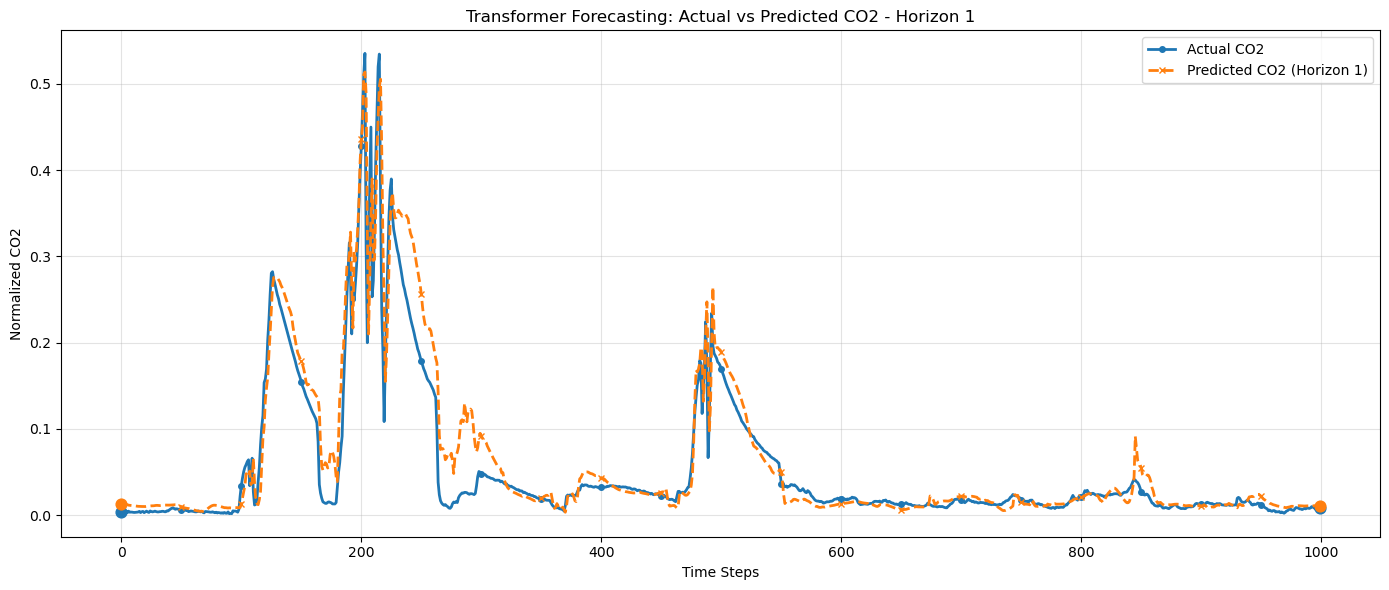

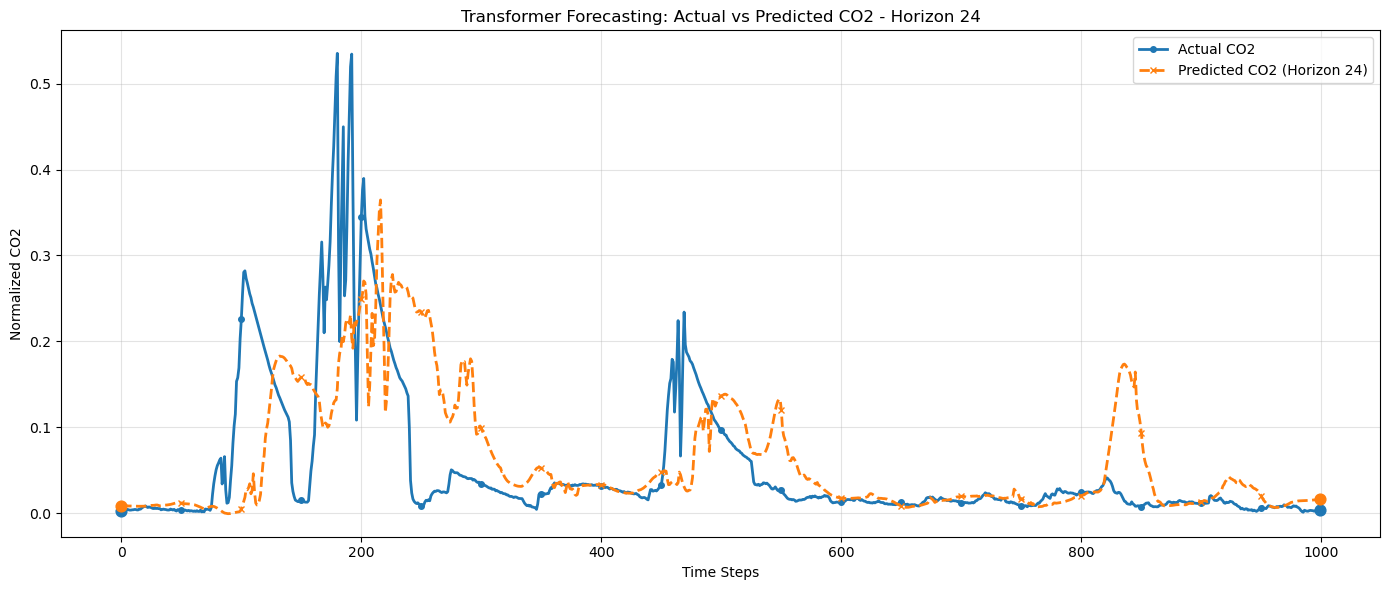

In [20]:
PLOT_SIZE = 1000

# Convert arrays to 2D so this works for OUTPUT_LENGTH = 1, 6, 12, 24, etc.
actual_2d = np.asarray(actual)
predictions_2d = np.asarray(predictions)

if actual_2d.ndim == 1:
    actual_2d = actual_2d.reshape(-1, 1)

if predictions_2d.ndim == 1:
    predictions_2d = predictions_2d.reshape(-1, 1)

horizon = predictions_2d.shape[1]

# The actual target signal is aligned to the selected prediction horizon.
horizons_to_plot = [1]

if horizon > 1:
    horizons_to_plot.append(horizon)

for horizon_to_compare in horizons_to_plot:

    # Create one separate graph for each horizon.
    plt.figure(figsize=(14, 6))

    # Plot only if this horizon exists in the model output.
    if horizon >= horizon_to_compare:

        horizon_index = horizon_to_compare - 1

        # Actual values
        actual_values = actual_2d[:, horizon_index]

        # Predicted values
        predicted_values = predictions_2d[:, horizon_index]

        plot_size = min(PLOT_SIZE, len(actual_values), len(predicted_values))
        time_steps = np.arange(plot_size)

        plt.plot(
            time_steps,
            actual_values[:plot_size],
            label=f"Actual {target_label}",
            linewidth=2,
            marker="o",
            markevery=50,
            markersize=4
        )

        plt.plot(
            time_steps,
            predicted_values[:plot_size],
            label=f"Predicted {target_label} (Horizon {horizon_to_compare})",
            linewidth=2,
            linestyle="--",
            marker="x",
            markevery=50,
            markersize=5
        )

        # Highlight the first and last plotted points.
        plt.scatter(
            [time_steps[0], time_steps[-1]],
            [actual_values[:plot_size][0], actual_values[:plot_size][-1]],
            s=60,
            zorder=5
        )

        plt.scatter(
            [time_steps[0], time_steps[-1]],
            [predicted_values[:plot_size][0], predicted_values[:plot_size][-1]],
            s=60,
            zorder=5
        )

        # Plot formatting
        plt.title(f"Transformer Forecasting: Actual vs Predicted {target_label} - Horizon {horizon_to_compare}")
        plt.xlabel("Time Steps")
        plt.ylabel(f"Normalized {target_label}")
        plt.legend()
        plt.grid(True, alpha=0.35)

    else:

        # Plot formatting when the requested horizon is not available.
        plt.title(f"Horizon {horizon_to_compare} Not Available")
        plt.text(
            0.5,
            0.5,
            f"OUTPUT_LENGTH = {horizon}\nTrain with OUTPUT_LENGTH >= {horizon_to_compare}",
            ha="center",
            va="center",
            transform=plt.gca().transAxes,
            fontsize=12
        )
        plt.xlabel("Time Steps")
        plt.ylabel(f"Normalized {target_label}")
        plt.grid(True, alpha=0.35)

    plt.tight_layout()
    plt.show()

In [21]:
# Save trained model
torch.save(model.state_dict(), "transformer_h72_o12.pth")

print("Model saved successfully!")

Model saved successfully!


In [22]:
import numpy as np

np.save("predictions.npy", predictions)
np.save("actual.npy", actual)

print("Predictions saved!")

Predictions saved!


## Training and Validation Loss Visualization

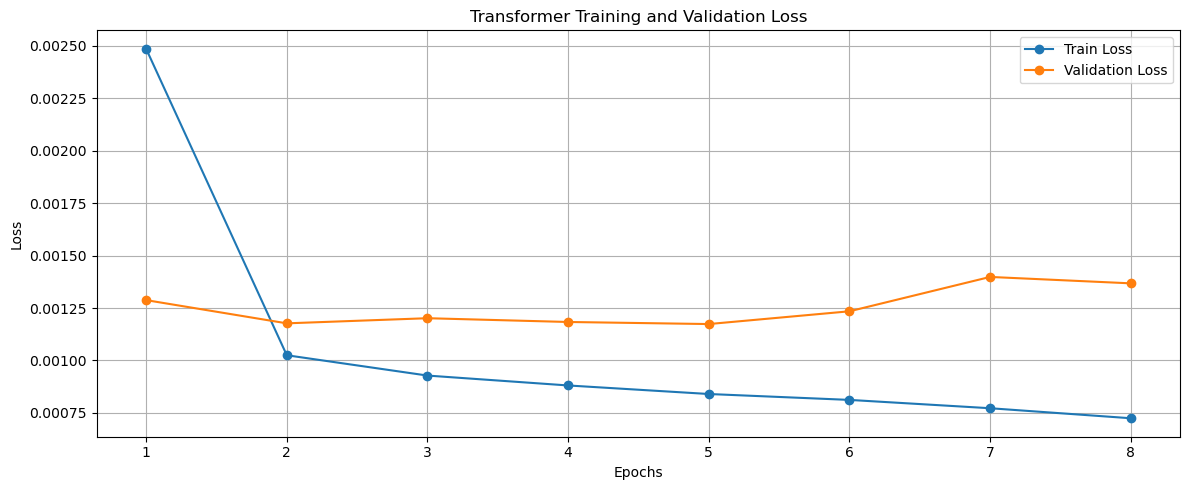

In [23]:
plt.figure(figsize=(12, 5))

# Training loss
plt.plot(
    range(1, EPOCHS + 1),
    train_losses,
    marker="o",
    label="Train Loss"
)

# Validation loss
plt.plot(
    range(1, EPOCHS + 1),
    val_losses,
    marker="o",
    label="Validation Loss"
)

# Plot formatting
plt.title("Transformer Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [24]:
best_val_loss = float("inf")

if avg_val_loss < best_val_loss:
    best_val_loss = avg_val_loss
    torch.save(model.state_dict(), "best_transformer.pth")

# Explainability Analysis

To improve the interpretability of the Transformer forecasting model, Explainable Artificial Intelligence (XAI) techniques were applied.

The objective of this analysis is to understand:

- Which historical observations influence future predictions.
- How the Transformer distributes attention across time.
- Which sensor variables contribute most to forecasting performance.

Two explainability techniques are used:

1. Attention Weight Analysis
2. Feature Ablation Analysis

## Technique 1: Attention Weight Analysis

The Transformer model uses multi-head self-attention to identify important historical observations when generating future forecasts.

This analysis investigates how attention is distributed across the input sequence.


In [25]:

print(model)

for name, module in model.named_modules():
    if isinstance(module, nn.MultiheadAttention):
        print("\nFound MultiheadAttention Layer:")
        print(name)

TransformerModel(
  (input_projection): Linear(in_features=12, out_features=64, bias=True)
  (positional_encoding): PositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (fc): Linear(in_features=64, out_features=24, bias=True)
)

Found MultiheadAttention Layer:
transformer_e

### Step 1: Attention Weight Extraction Verification

Attention weights are extracted from the first Transformer encoder layer.

To obtain more representative results, attention is analyzed across 100 test samples rather than a single example.

In [26]:
num_samples = 100

sample_batch = X_test[:num_samples].to(device)

print("Sample shape:", sample_batch.shape)

with torch.no_grad():

    projected = model.input_projection(sample_batch)

    projected = model.positional_encoding(projected)

    attention_output, attention_weights = (
        model.transformer_encoder.layers[0].self_attn(
            projected,
            projected,
            projected,
            need_weights=True,
            average_attn_weights=False
        )
    )

print("Attention output shape:")
print(attention_output.shape)

print("\nAttention weights shape:")
print(attention_weights.shape)

Sample shape: torch.Size([100, 96, 12])
Attention output shape:
torch.Size([100, 96, 64])

Attention weights shape:
torch.Size([100, 4, 96, 96])


### Step 2: Attention Heatmap Visualization

The attention heatmap illustrates how strongly each timestep attends to other timesteps within the historical sequence.

Higher attention values indicate greater influence on forecasting decisions.


Attention Matrix Shape: (96, 96)


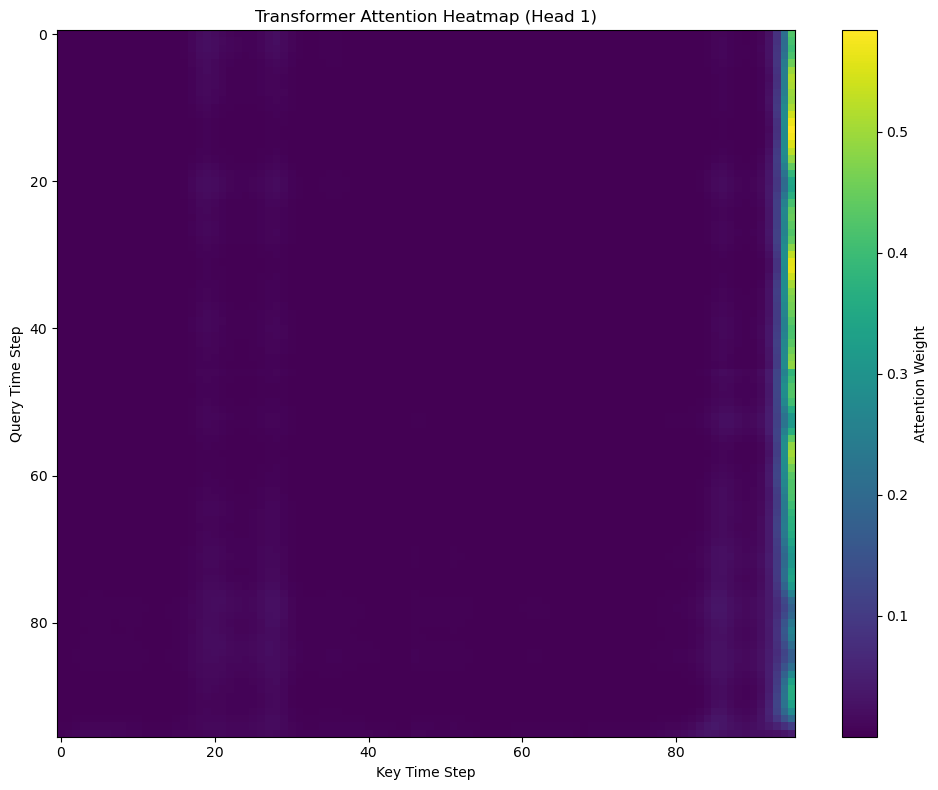

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Select first sample
attention_matrix = (
    attention_weights[0, 0]  # Sample 0, Head 0
    .cpu()
    .numpy()
)

print("Attention Matrix Shape:", attention_matrix.shape)

plt.figure(figsize=(10, 8))

plt.imshow(
    attention_matrix,
    aspect="auto",
    cmap="viridis"
)

plt.colorbar(label="Attention Weight")

plt.title(
    "Transformer Attention Heatmap (Head 1)"
)

plt.xlabel("Key Time Step")
plt.ylabel("Query Time Step")

plt.tight_layout()
plt.show()

### Step 3: Average Multi-Head Attention Analysis

Attention scores are averaged across all attention heads and multiple test samples to obtain a global view of temporal importance.

This provides a more stable representation of model behaviour.


Average Attention Shape: (96, 96)


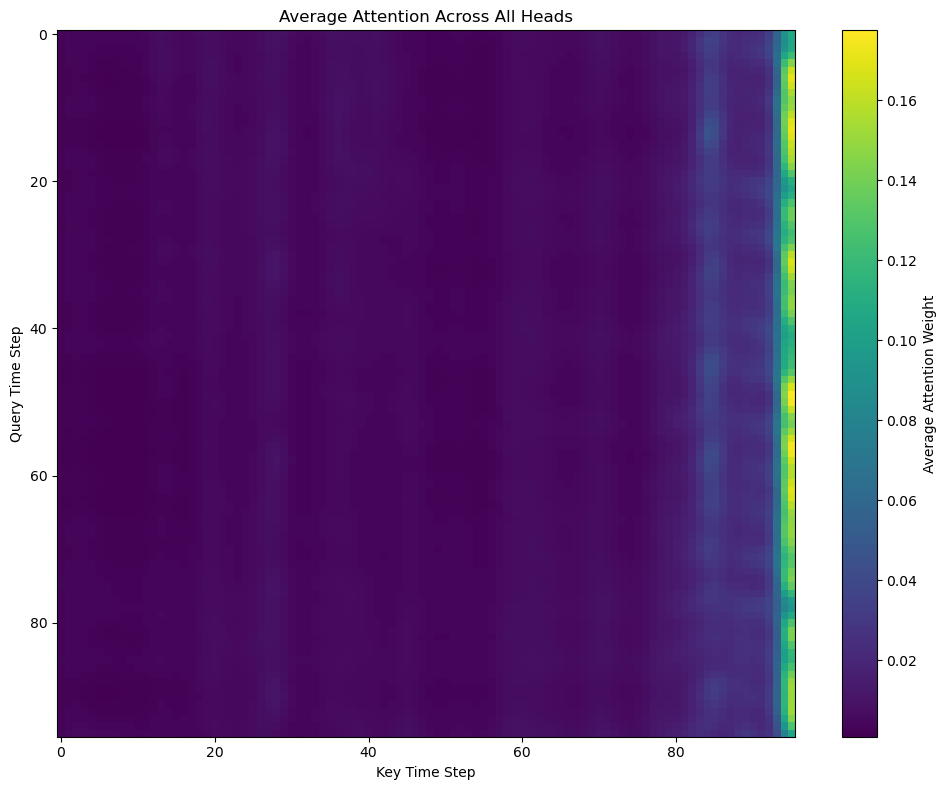

In [28]:
# Average across all 4 heads
avg_attention = (
    attention_weights
    .mean(dim=(0,1))
    .cpu()
    .numpy()
)

print("Average Attention Shape:", avg_attention.shape)

plt.figure(figsize=(10, 8))

plt.imshow(
    avg_attention,
    aspect="auto",
    cmap="viridis"
)

plt.colorbar(label="Average Attention Weight")

plt.title(
    "Average Attention Across All Heads"
)

plt.xlabel("Key Time Step")
plt.ylabel("Query Time Step")

plt.tight_layout()
plt.show()

## Step 4: Most Important Historical Timesteps

Top 10 Most Important Timesteps
Rank 1: Timestep 95 (Importance = 0.1414)
Rank 2: Timestep 94 (Importance = 0.1186)
Rank 3: Timestep 93 (Importance = 0.0617)
Rank 4: Timestep 92 (Importance = 0.0321)
Rank 5: Timestep 85 (Importance = 0.0314)
Rank 6: Timestep 84 (Importance = 0.0314)
Rank 7: Timestep 86 (Importance = 0.0264)
Rank 8: Timestep 83 (Importance = 0.0249)
Rank 9: Timestep 91 (Importance = 0.0246)
Rank 10: Timestep 90 (Importance = 0.0239)


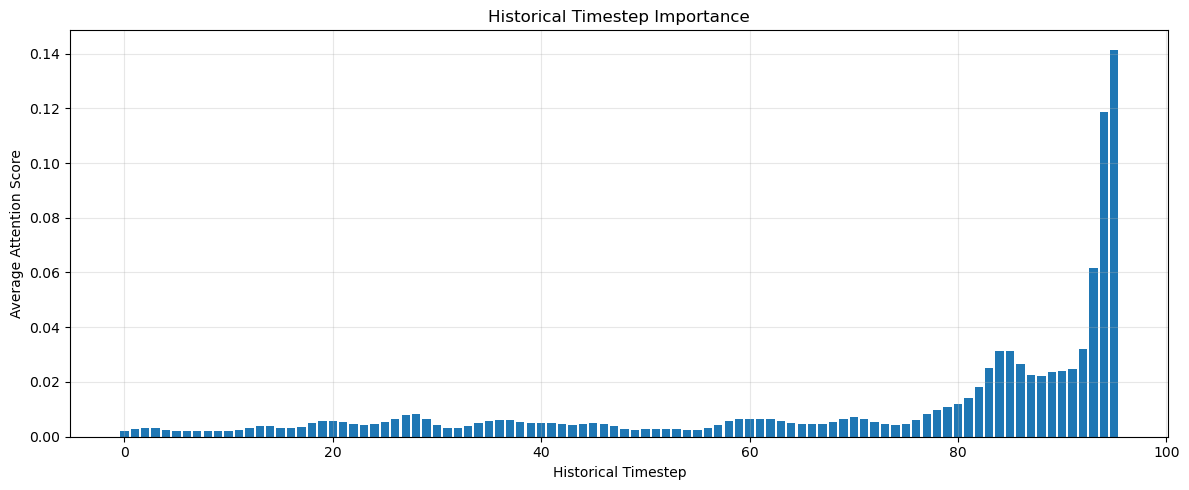

In [29]:
# Average attention over all query positions
importance_scores = avg_attention.mean(axis=0)

# Top 10 most important timesteps
top_k = 10

top_indices = np.argsort(importance_scores)[-top_k:][::-1]

print("Top 10 Most Important Timesteps")

for rank, idx in enumerate(top_indices, start=1):
    print(
        f"Rank {rank}: "
        f"Timestep {idx} "
        f"(Importance = {importance_scores[idx]:.4f})"
    )

# Visualization
plt.figure(figsize=(12,5))

plt.bar(
    range(len(importance_scores)),
    importance_scores
)

plt.title(
    "Historical Timestep Importance"
)

plt.xlabel("Historical Timestep")
plt.ylabel("Average Attention Score")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Step 4.1 Top Historical Timesteps

To better interpret the attention mechanism, the ten most influential historical timesteps are extracted and ranked according to their average attention scores.

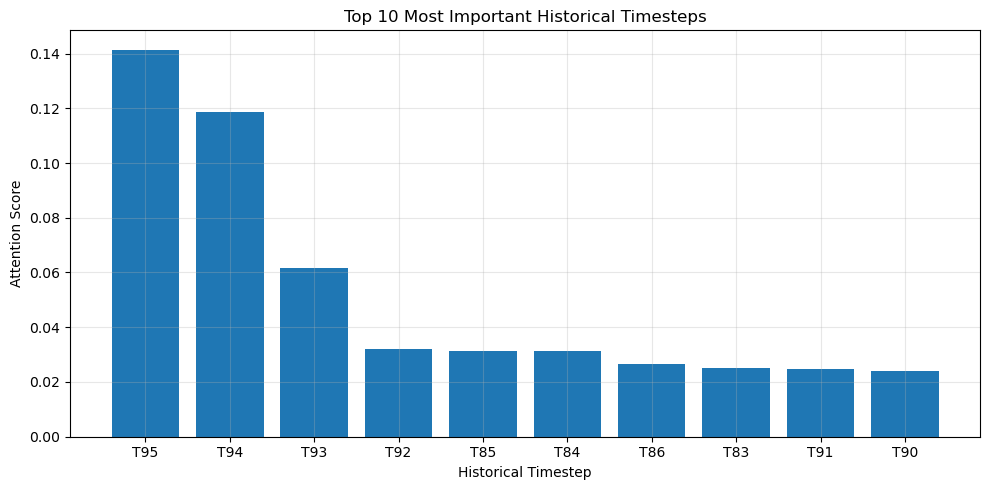

In [30]:
# Top 10 Visualization

plt.figure(figsize=(10,5))

plt.bar(
    range(top_k),
    importance_scores[top_indices]
)

plt.xticks(
    range(top_k),
    [f"T{idx}" for idx in top_indices]
)

plt.title(
    "Top 10 Most Important Historical Timesteps"
)

plt.xlabel("Historical Timestep")
plt.ylabel("Attention Score")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Step 5: Attention Head Comparison

Different attention heads may focus on different temporal patterns.

Comparing individual heads helps identify whether the Transformer learns multiple forecasting relationships simultaneously.


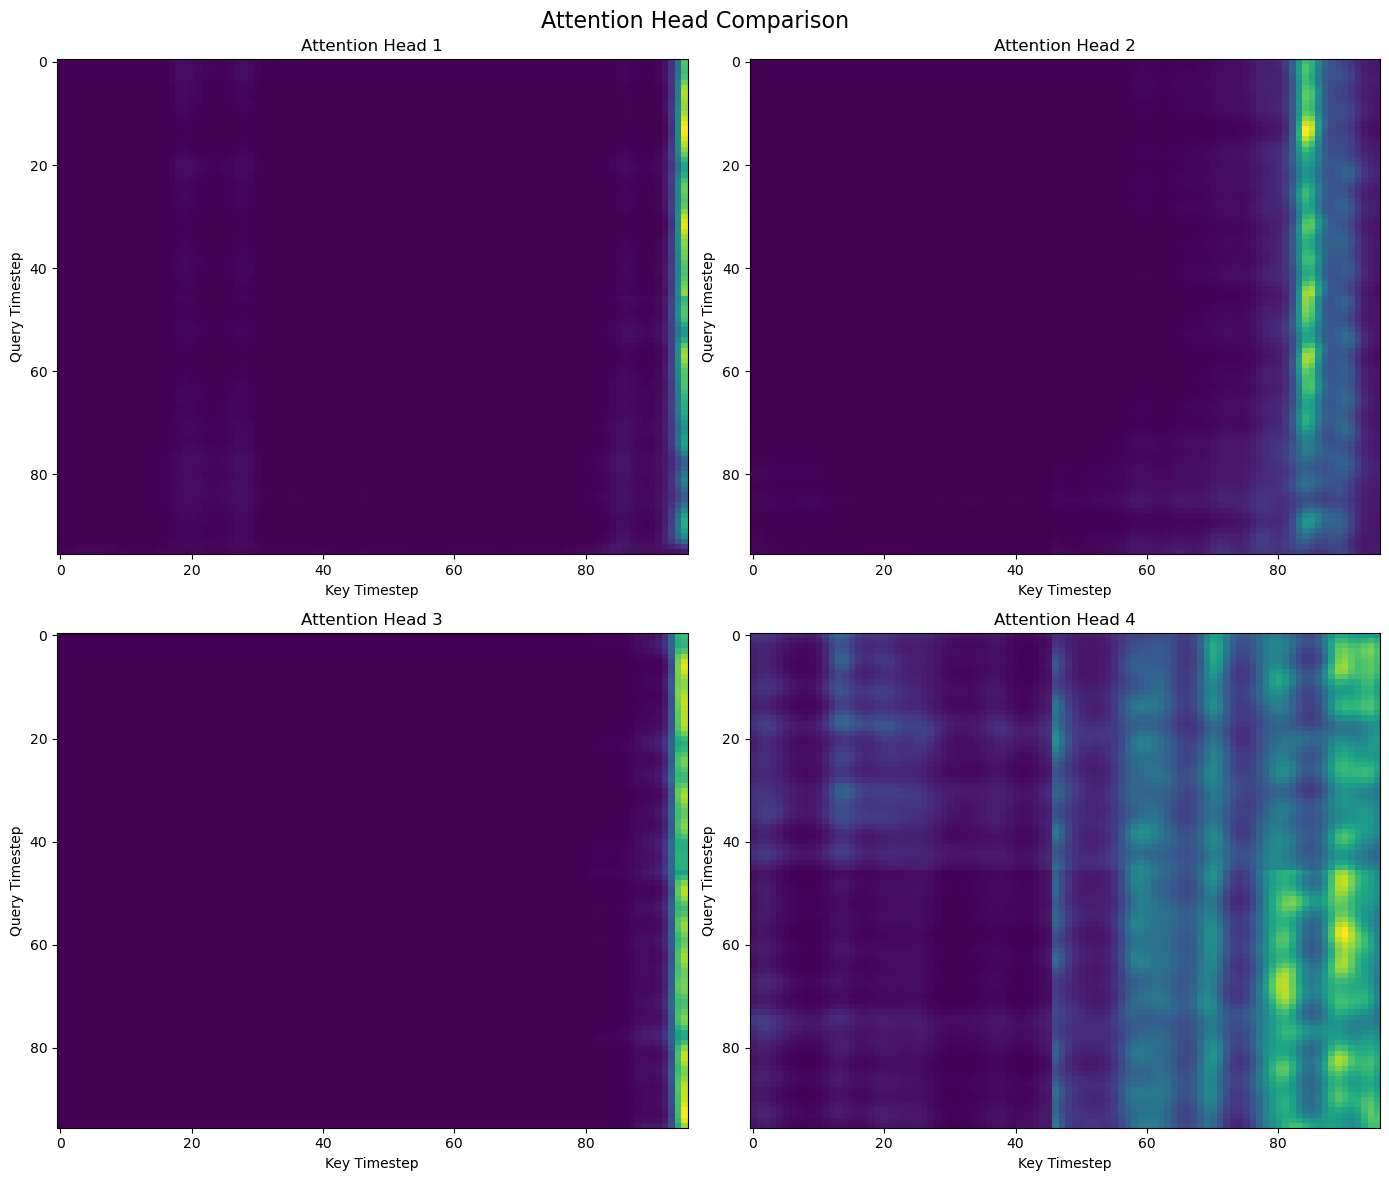

In [31]:
import matplotlib.pyplot as plt

sample_attention = attention_weights[0]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 12)
)

for head_idx, ax in enumerate(axes.flat):

    head_attention = (
        sample_attention[head_idx]
        .cpu()
        .numpy()
    )

    im = ax.imshow(
        head_attention,
        aspect="auto",
        cmap="viridis"
    )

    ax.set_title(
        f"Attention Head {head_idx + 1}"
    )

    ax.set_xlabel("Key Timestep")
    ax.set_ylabel("Query Timestep")

plt.suptitle(
    "Attention Head Comparison",
    fontsize=16
)

plt.tight_layout()

plt.show()

## Technique 2: Feature Ablation Analysis

Feature ablation analysis is performed to quantify the contribution of individual sensor variables to forecasting performance.

The procedure removes one feature at a time from the input sequence and measures the resulting degradation in model accuracy.

Features that produce larger performance degradation are considered more important for future CO₂ prediction.


## Step 1: Baseline Performance

In [32]:
baseline_rmse = rmse
baseline_mae = mae

print("Baseline RMSE:", baseline_rmse)
print("Baseline MAE :", baseline_mae)

Baseline RMSE: 0.04164800871895068
Baseline MAE : 0.023164689540863037


# Step 2: Feature Selection for Ablation

In [33]:
ablation_features = [
    "scd41_co2",
    "scd41_temperature",
    "scd41_humidity",
    "ens160_aqi",
    "ens160_tvoc",
    "bme688_gas_resistance"
]

print("Features Selected For Ablation:")

for feature in ablation_features:
    print("-", feature)

Features Selected For Ablation:
- scd41_co2
- scd41_temperature
- scd41_humidity
- ens160_aqi
- ens160_tvoc
- bme688_gas_resistance


## Step 3: Single Feature Ablation Verification

In [34]:
feature_to_test = "scd41_co2"

feature_idx = feature_columns.index(
    feature_to_test
)

X_test_ablation = X_test.clone()

# Remove feature information
X_test_ablation[:, :, feature_idx] = 0

predictions_ablation = []

model.eval()

with torch.no_grad():

    for start_idx in range(
        0,
        len(X_test_ablation),
        BATCH_SIZE
    ):

        batch = X_test_ablation[
            start_idx:start_idx+BATCH_SIZE
        ].to(device)

        outputs = model(batch)

        predictions_ablation.extend(
            outputs.cpu().numpy()
        )

predictions_ablation = np.array(
    predictions_ablation
)

rmse_ablation = np.sqrt(
    mean_squared_error(
        actual,
        predictions_ablation
    )
)

mae_ablation = mean_absolute_error(
    actual,
    predictions_ablation
)

print("Feature Removed:", feature_to_test)

print("Baseline RMSE :", baseline_rmse)
print("New RMSE      :", rmse_ablation)

print(
    "RMSE Increase :",
    rmse_ablation - baseline_rmse
)

print("\nBaseline MAE :", baseline_mae)
print("New MAE      :", mae_ablation)

Feature Removed: scd41_co2
Baseline RMSE : 0.04164800871895068
New RMSE      : 0.09053727108905246
RMSE Increase : 0.048889262370101785

Baseline MAE : 0.023164689540863037
New MAE      : 0.04964016005396843


## Step 4: Multi-Feature Ablation Analysis

In [35]:
ablation_features = [
    "scd41_co2",
    "scd41_temperature",
    "scd41_humidity",
    "ens160_aqi",
    "ens160_tvoc",
    "bme688_gas_resistance",
    "bme688_pressure"
]

ablation_results = []

model.eval()

for feature in ablation_features:

    feature_idx = feature_columns.index(feature)

    X_test_ablation = X_test.clone()

    # Remove feature information
    X_test_ablation[:, :, feature_idx] = 0

    predictions_ablation = []

    with torch.no_grad():

        for start_idx in range(
            0,
            len(X_test_ablation),
            BATCH_SIZE
        ):

            batch = X_test_ablation[
                start_idx:start_idx+BATCH_SIZE
            ].to(device)

            outputs = model(batch)

            predictions_ablation.extend(
                outputs.cpu().numpy()
            )

    predictions_ablation = np.array(
        predictions_ablation
    )

    rmse_ablation = np.sqrt(
        mean_squared_error(
            actual,
            predictions_ablation
        )
    )

    mae_ablation = mean_absolute_error(
        actual,
        predictions_ablation
    )

    ablation_results.append({
        "Feature": feature,
        "RMSE": rmse_ablation,
        "MAE": mae_ablation,
        "RMSE Increase":
            rmse_ablation - baseline_rmse
    })

ablation_results = pd.DataFrame(
    ablation_results
)

ablation_results = ablation_results.sort_values(
    "RMSE Increase",
    ascending=False
)

ablation_results

,Feature,RMSE,MAE,RMSE Increase
1,scd41_temperature,0.144085,0.096327,0.102437
0,scd41_co2,0.090537,0.049640,0.048889
6,bme688_pressure,0.053145,0.031510,0.011497
3,ens160_aqi,0.045231,0.024965,0.003583
2,scd41_humidity,0.041800,0.022443,0.000152
5,bme688_gas_resistance,0.041648,0.023165,0.000000
4,ens160_tvoc,0.041394,0.022878,-0.000254


## Step 5: Feature Importance Visualization

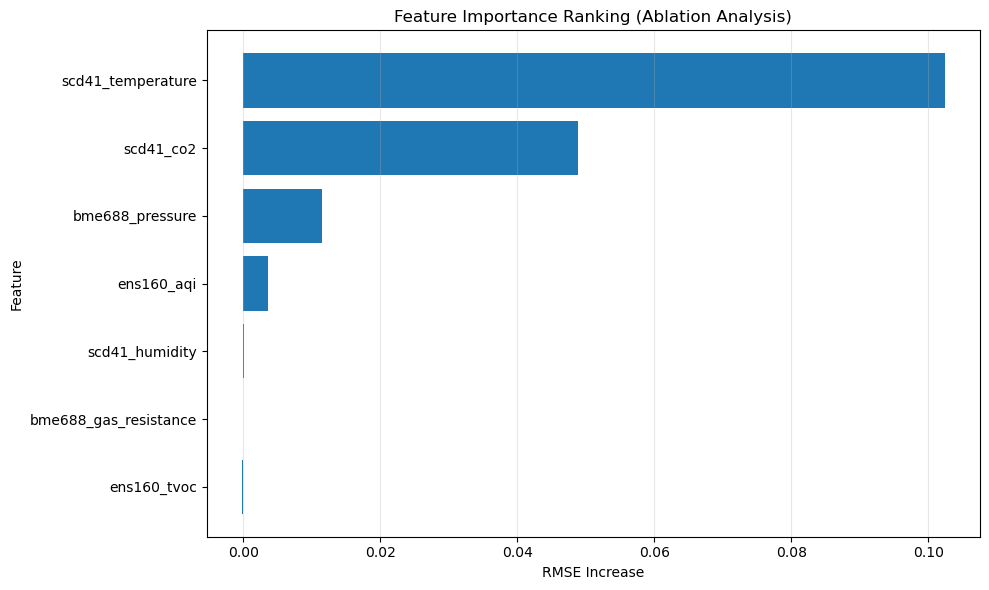

In [36]:
plt.figure(figsize=(10,6))

plot_df = ablation_results.sort_values(
    "RMSE Increase",
    ascending=True
)

plt.barh(
    plot_df["Feature"],
    plot_df["RMSE Increase"]
)

plt.xlabel("RMSE Increase")
plt.ylabel("Feature")

plt.title(
    "Feature Importance Ranking (Ablation Analysis)"
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()
plt.show()

# Uncertainty Quantification

In addition to generating accurate point forecasts, it is important to quantify the uncertainty associated with model predictions.

Uncertainty estimation provides information about the confidence of the forecasting model and helps assess the reliability of future predictions.

To achieve this, Monte Carlo Dropout is employed as an approximate Bayesian inference technique. During inference, dropout layers remain active and multiple stochastic forward passes are performed using the same input sequence.

The resulting prediction distribution is used to estimate:

- Mean forecasts
- Prediction variability
- Confidence intervals
- Forecast uncertainty across prediction horizons

This analysis enables the Transformer model to provide both predictions and uncertainty estimates, improving the interpretability and trustworthiness of the forecasting framework.

## Technique 1: Monte Carlo Dropout

Monte Carlo Dropout is used to estimate predictive uncertainty by performing multiple stochastic forward passes through the trained Transformer model.

Unlike standard inference, dropout layers remain active during prediction, producing slightly different forecasts for the same input sequence. The variability of these predictions is used to quantify model uncertainty and construct confidence intervals.

Step 1: Verify Dropout Layers

In [37]:
print(model)

dropout_count = 0

for name, module in model.named_modules():

    if isinstance(module, nn.Dropout):

        dropout_count += 1

        print(
            f"Dropout Layer {dropout_count}:",
            name
        )

print(
    "\nTotal Dropout Layers:",
    dropout_count
)

TransformerModel(
  (input_projection): Linear(in_features=12, out_features=64, bias=True)
  (positional_encoding): PositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (fc): Linear(in_features=64, out_features=24, bias=True)
)
Dropout Layer 1: transformer_encoder.layers.0.

## Step 2: Monte Carlo Prediction Verification

In [38]:
sample = X_test[:1].to(device)

mc_predictions = []

model.train()

with torch.no_grad():

    for i in range(10):

        prediction = model(sample)

        mc_predictions.append(
            prediction.cpu().numpy()
        )

mc_predictions = np.array(
    mc_predictions
)

print(
    "MC Prediction Shape:"
)

print(
    mc_predictions.shape
)

print(
    "\nFirst Prediction:"
)

print(
    mc_predictions[0]
)

print(
    "\nSecond Prediction:"
)

print(
    mc_predictions[1]
)

MC Prediction Shape:
(10, 1, 24)

First Prediction:
[[0.013061   0.01243685 0.01190708 0.01080064 0.0127819  0.01247267
  0.01071276 0.01165216 0.01240818 0.01246331 0.01266648 0.01263683
  0.01263575 0.01274144 0.01373554 0.0114021  0.01182779 0.01360851
  0.01232744 0.01332018 0.0105583  0.01223691 0.01096707 0.00914697]]

Second Prediction:
[[0.02338982 0.02316436 0.02280159 0.02185319 0.02137214 0.02139795
  0.02003115 0.02071292 0.02092246 0.02079727 0.01929005 0.01988368
  0.02067122 0.01987194 0.01876233 0.01837948 0.01754486 0.01772939
  0.01692645 0.01683836 0.01576388 0.01504469 0.01376285 0.01285487]]


## Step 3: Monte Carlo Sampling

In [39]:
sample = X_test[:1].to(device)

mc_predictions = []

model.train()

with torch.no_grad():

    for i in range(100):

        prediction = model(sample)

        mc_predictions.append(
            prediction.cpu().numpy()
        )

mc_predictions = np.array(
    mc_predictions
)

print(
    "MC Prediction Shape:"
)

print(
    mc_predictions.shape
)

MC Prediction Shape:
(100, 1, 24)


## Step 4: Uncertainty Statistics

In [40]:
mc_mean = np.mean(
    mc_predictions,
    axis=0
)

mc_std = np.std(
    mc_predictions,
    axis=0
)

lower_bound = (
    mc_mean - 1.96 * mc_std
)

upper_bound = (
    mc_mean + 1.96 * mc_std
)

print("Mean Prediction:")
print(mc_mean)

print("\nStandard Deviation:")
print(mc_std)

print("\nLower Bound:")
print(lower_bound)

print("\nUpper Bound:")
print(upper_bound)

Mean Prediction:
[[0.01601196 0.01552153 0.01538943 0.01421643 0.01555975 0.01523827
  0.01404718 0.01491344 0.01589808 0.01648945 0.01561488 0.01705582
  0.01688443 0.01660094 0.01649288 0.01553133 0.0157577  0.0159601
  0.01477783 0.01474682 0.01320207 0.01351585 0.01188267 0.01079729]]

Standard Deviation:
[[0.00506548 0.00520823 0.00520236 0.00525137 0.00494174 0.0047509
  0.00476612 0.00470659 0.00449428 0.00445369 0.00438504 0.00426425
  0.00432458 0.00437803 0.00442732 0.0044222  0.00423568 0.00410575
  0.00391522 0.00399074 0.00393154 0.00379125 0.00366457 0.00388681]]

Lower Bound:
[[0.00608362 0.00531339 0.00519279 0.00392374 0.00587394 0.0059265
  0.00470558 0.00568854 0.00708929 0.00776022 0.00702021 0.00869788
  0.00840825 0.00802    0.00781533 0.00686382 0.00745577 0.00791284
  0.007104   0.00692497 0.00549624 0.00608499 0.00470012 0.00317914]]

Upper Bound:
[[0.0259403  0.02572967 0.02558606 0.02450911 0.02524555 0.02455003
  0.02338879 0.02413835 0.02470687 0.02521867 0

## Step 5: Prediction Distribution Analysis

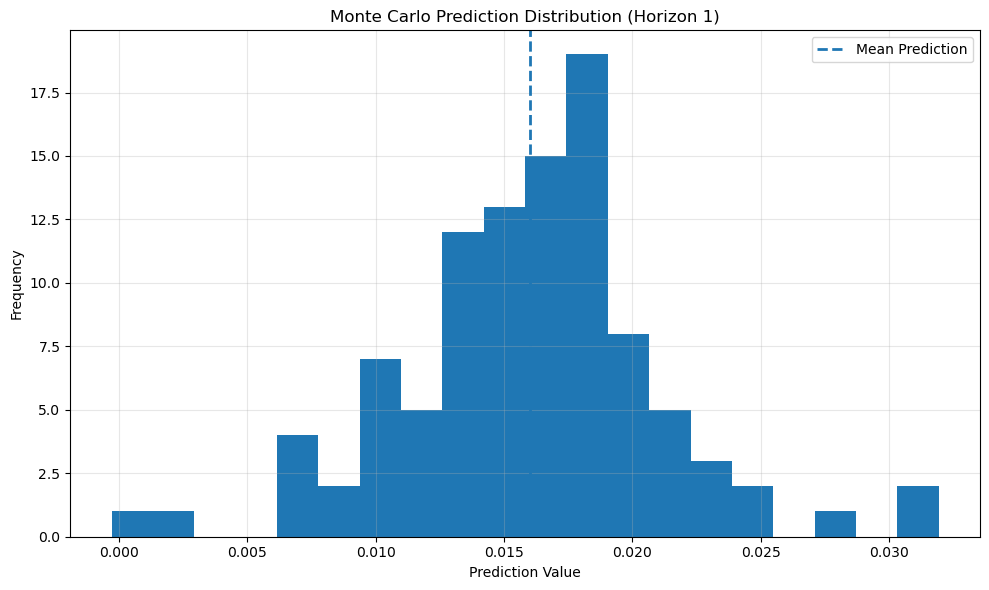

In [41]:
plt.figure(figsize=(10,6))

plt.hist(
    mc_predictions[:,0,0],
    bins=20
)

plt.axvline(
    mc_mean[0,0],
    linestyle="--",
    linewidth=2,
    label="Mean Prediction"
)

plt.title(
    "Monte Carlo Prediction Distribution (Horizon 1)"
)

plt.xlabel("Prediction Value")
plt.ylabel("Frequency")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Step 6: Confidence Interval Forecast Visualization

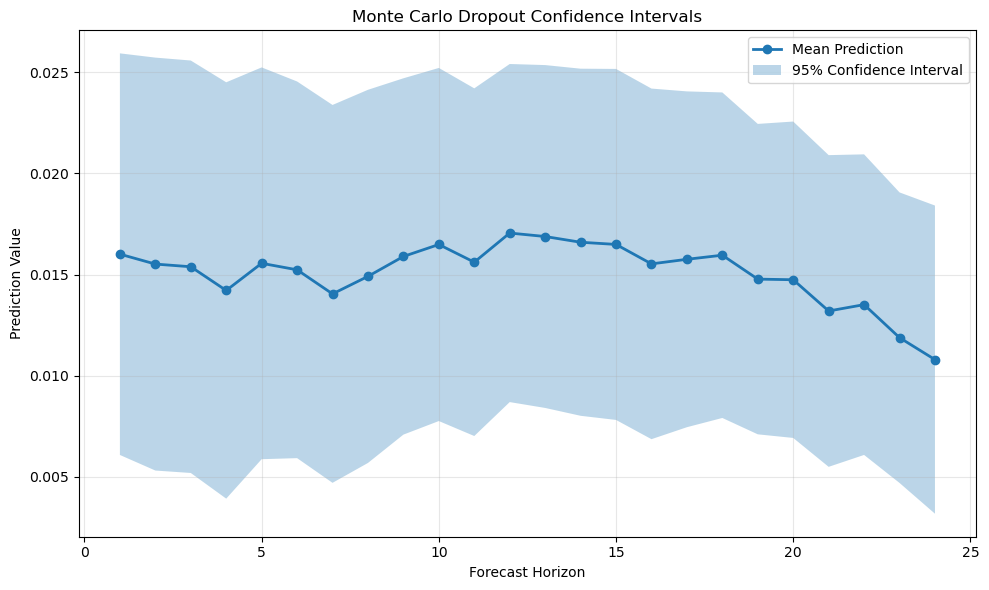

In [42]:
#horizons = np.arange(1, 7)
horizons = np.arange(1, OUTPUT_LENGTH + 1)
plt.figure(figsize=(10,6))

plt.plot(
    horizons,
    mc_mean[0],
    marker="o",
    linewidth=2,
    label="Mean Prediction"
)

plt.fill_between(
    horizons,
    lower_bound[0],
    upper_bound[0],
    alpha=0.3,
    label="95% Confidence Interval"
)

plt.xlabel("Forecast Horizon")
plt.ylabel("Prediction Value")

plt.title(
    "Monte Carlo Dropout Confidence Intervals"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Step 7: Uncertainty Summary Statistics

In [43]:
uncertainty_df = pd.DataFrame({

    #"Horizon": np.arange(1, 7),
    "Horizons": np.arange(1, OUTPUT_LENGTH + 1),

    "Mean Prediction": mc_mean[0],

    "Std Dev": mc_std[0],

    "Lower Bound": lower_bound[0],

    "Upper Bound": upper_bound[0]
})

uncertainty_df

,Horizons,Mean Prediction,Std Dev,Lower Bound,Upper Bound
0,1,0.016012,0.005065,0.006084,0.025940
1,2,0.015522,0.005208,0.005313,0.025730
2,3,0.015389,0.005202,0.005193,0.025586
3,4,0.014216,0.005251,0.003924,0.024509
4,5,0.015560,0.004942,0.005874,0.025246
5,6,0.015238,0.004751,0.005927,0.024550
6,7,0.014047,0.004766,0.004706,0.023389
7,8,0.014913,0.004707,0.005689,0.024138
8,9,0.015898,0.004494,0.007089,0.024707
9,10,0.016489,0.004454,0.007760,0.025219


In [44]:
print(actual.shape)
print(predictions.shape)

(29083, 24)
(29083, 24)


## Technique 2: Prediction Interval Evaluation

While Monte Carlo Dropout provides confidence intervals for individual forecasts, it is also necessary to evaluate the quality of these intervals across the entire test dataset.

Prediction interval evaluation assesses whether the generated confidence intervals successfully capture the true observed values.

Two metrics are used:

1. Prediction Interval Coverage Probability (PICP)
2. Mean Prediction Interval Width (MPIW)

Together, these metrics quantify both the reliability and sharpness of the uncertainty estimates.


### Step 1: Generate Prediction Intervals

Monte Carlo Dropout is applied to multiple test samples to generate stochastic forecasts.

The resulting prediction distributions are used to construct prediction intervals for each forecast horizon.

In [45]:
coverage_samples = X_test[:1000].to(device)

model.train()

mc_predictions_multi = []

with torch.no_grad():

    for i in range(100):

        pred = model(
            coverage_samples
        )

        mc_predictions_multi.append(
            pred.cpu().numpy()
        )

mc_predictions_multi = np.array(
    mc_predictions_multi
)

print(
    "MC Prediction Shape:"
)

print(
    mc_predictions_multi.shape
)

MC Prediction Shape:
(100, 1000, 24)


## Step 2: Compute Prediction Intervals

In [46]:
mc_mean_multi = np.mean(
    mc_predictions_multi,
    axis=0
)

mc_std_multi = np.std(
    mc_predictions_multi,
    axis=0
)

lower_multi = (
    mc_mean_multi - 2.58 * mc_std_multi
)

upper_multi = (
    mc_mean_multi + 2.58 * mc_std_multi
)

print("Mean Shape :", mc_mean_multi.shape)
print("Lower Shape:", lower_multi.shape)
print("Upper Shape:", upper_multi.shape)

Mean Shape : (1000, 24)
Lower Shape: (1000, 24)
Upper Shape: (1000, 24)


In [47]:
interval_width = (
    upper_multi - lower_multi
)

mpiw = np.mean(
    interval_width
)

print(
    "MPIW:",
    mpiw
)

MPIW: 0.036560208


### Step 3: Coverage Evaluation

In [48]:
actual_subset = actual[:1000]

inside_interval = (
    (actual_subset >= lower_multi) &
    (actual_subset <= upper_multi)
)

coverage_per_horizon = (
    inside_interval.mean(axis=0) * 100
)

for horizon, coverage in enumerate(
    coverage_per_horizon,
    start=1
):
    print(
        f"Horizon {horizon}: "
        f"{coverage:.2f}%"
    )
    

Horizon 1: 82.00%
Horizon 2: 78.80%
Horizon 3: 75.80%
Horizon 4: 71.20%
Horizon 5: 65.80%
Horizon 6: 60.90%
Horizon 7: 61.60%
Horizon 8: 59.40%
Horizon 9: 54.10%
Horizon 10: 51.50%
Horizon 11: 51.30%
Horizon 12: 44.00%
Horizon 13: 42.20%
Horizon 14: 42.20%
Horizon 15: 39.20%
Horizon 16: 42.90%
Horizon 17: 38.90%
Horizon 18: 38.40%
Horizon 19: 37.70%
Horizon 20: 37.20%
Horizon 21: 41.20%
Horizon 22: 37.20%
Horizon 23: 40.50%
Horizon 24: 42.50%


## Step 4: Prediction Interval Coverage Visualization

In [49]:
coverage_df = pd.DataFrame({
    #"Horizon": np.arange(1, 7),
    "Horizons": np.arange(1, OUTPUT_LENGTH + 1),
    "Coverage (%)": coverage_per_horizon
})

coverage_df

,Horizons,Coverage (%)
0,1,82.0
1,2,78.8
2,3,75.8
3,4,71.2
4,5,65.8
5,6,60.9
6,7,61.6
7,8,59.4
8,9,54.1
9,10,51.5


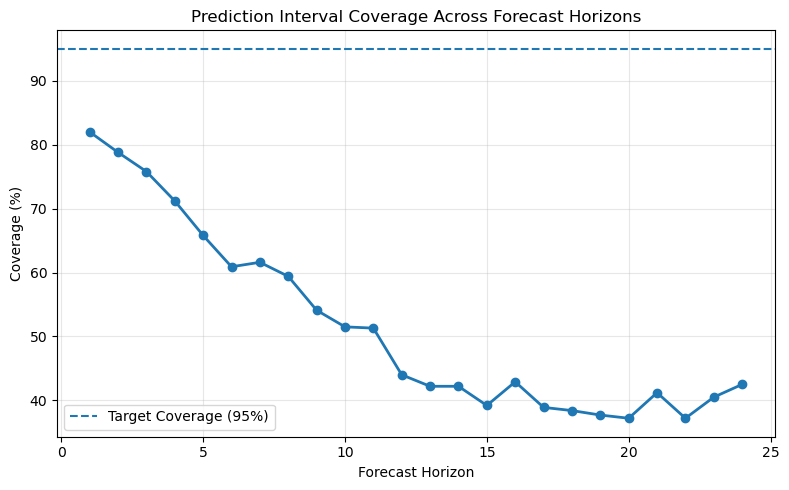

In [50]:
plt.figure(figsize=(8,5))

plt.plot(
    coverage_df["Horizons"],
    coverage_df["Coverage (%)"],
    marker="o",
    linewidth=2
)

plt.axhline(
    y=95,
    linestyle="--",
    label="Target Coverage (95%)"
)

plt.xlabel("Forecast Horizon")
plt.ylabel("Coverage (%)")

plt.title(
    "Prediction Interval Coverage Across Forecast Horizons"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [51]:
from sklearn.metrics import r2_score

r2 = r2_score(
    actual.flatten(),
    predictions.flatten()
)

print(f"R² Score : {r2:.6f}")

R² Score : 0.732049


## Technique 2: Forecast Horizon Error Analysis

Forecast accuracy is evaluated separately for each prediction horizon.

This analysis investigates how forecasting performance changes as the prediction horizon increases.

Root Mean Squared Error (RMSE) is calculated for each forecast horizon to assess both short-term and long-term prediction accuracy.

### Step 1: Compute RMSE for Each Forecast Horizon

In [52]:
horizon_rmse = []

for horizon in range(OUTPUT_LENGTH):

    rmse_h = np.sqrt(
        mean_squared_error(
            actual[:, horizon],
            predictions[:, horizon]
        )
    )

    horizon_rmse.append(
        rmse_h
    )

horizon_rmse

[np.float64(0.02088570546750612),
 np.float64(0.023314475993678658),
 np.float64(0.026239414482666926),
 np.float64(0.02906620891231322),
 np.float64(0.03302714928389856),
 np.float64(0.035029670212444186),
 np.float64(0.03610398457072732),
 np.float64(0.03763046010196064),
 np.float64(0.03993432663102582),
 np.float64(0.04191575190933674),
 np.float64(0.043535123534551814),
 np.float64(0.044537020401442744),
 np.float64(0.04431707174071307),
 np.float64(0.04427397269216112),
 np.float64(0.04474379653062358),
 np.float64(0.04561587108852879),
 np.float64(0.04622522652368349),
 np.float64(0.047347616771124174),
 np.float64(0.048912226251621636),
 np.float64(0.048972961668096844),
 np.float64(0.048849692349895155),
 np.float64(0.0489087821454231),
 np.float64(0.04980433688320836),
 np.float64(0.04912525608712465)]

In [53]:
horizon_df = pd.DataFrame({

    "Forecast Horizon":
        np.arange(
            1,
            OUTPUT_LENGTH + 1
        ),

    "RMSE":
        horizon_rmse
})

horizon_df

,Forecast Horizon,RMSE
0,1,0.020886
1,2,0.023314
2,3,0.026239
3,4,0.029066
4,5,0.033027
5,6,0.035030
6,7,0.036104
7,8,0.037630
8,9,0.039934
9,10,0.041916


### Step 2: Forecast Horizon Error Visualization

A horizon-wise RMSE curve is generated to analyze how prediction errors evolve across future forecasting horizons.

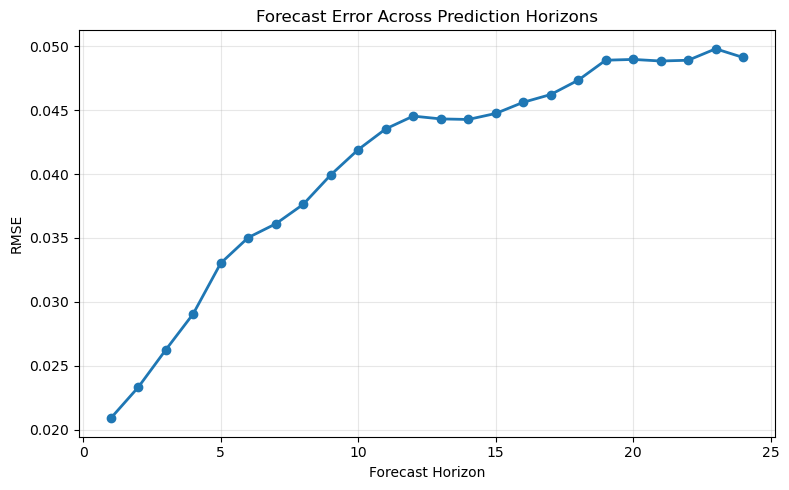

In [54]:
plt.figure(figsize=(8,5))

plt.plot(
    horizon_df["Forecast Horizon"],
    horizon_df["RMSE"],
    marker="o",
    linewidth=2
)

plt.xlabel(
    "Forecast Horizon"
)

plt.ylabel(
    "RMSE"
)

plt.title(
    "Forecast Error Across Prediction Horizons"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [55]:
print("Best Horizon RMSE :", min(horizon_rmse))
print("Worst Horizon RMSE:", max(horizon_rmse))

print(
    "RMSE Increase (%):",
    (
        (max(horizon_rmse) - min(horizon_rmse))
        / min(horizon_rmse)
    ) * 100
)

Best Horizon RMSE : 0.02088570546750612
Worst Horizon RMSE: 0.04980433688320836
RMSE Increase (%): 138.46135798809237


In [56]:
temp_features = [

    np.mean(temp_scattering),

    np.std(temp_scattering),

    np.max(temp_scattering),

    np.min(temp_scattering)
]

co2_features = [

    np.mean(co2_scattering),

    np.std(co2_scattering),

    np.max(co2_scattering),

    np.min(co2_scattering)
]

wavelet_features = np.concatenate([
    temp_features,
    co2_features
])

print(
    "Wavelet Feature Vector Shape:"
)

print(
    wavelet_features.shape
)

NameError: name 'temp_scattering' is not defined

In [ ]:
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(113528, 13)
(44163, 13)
(29203, 13)
